In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anishaananth/sleep-posture-classify/README.dataset.txt
/kaggle/input/datasets/anishaananth/sleep-posture-classify/README.roboflow.txt
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/prone/S03_001_jpg.rf.f65b0b5306d03b23db86fc0f18adfaaa.jpg
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/prone/S02_007_jpg.rf.62b63d0af8c9e1ba93426cc2f12dfeb6.jpg
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/prone/S02_010_jpg.rf.4285b00231d395e7d52da39f58b355aa.jpg
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/prone/S02_001_jpg.rf.880c459a3d9db79b9027360094a750a5.jpg
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/prone/S03_005_jpg.rf.11d0604a887ead0e3cdaac1ecf3b147d.jpg
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/prone/S02_004_jpg.rf.35822ec9225033ee13f1facced32365e.jpg
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/prone/S02_011_jpg.rf.c25290b00507ff5d4ec

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files[:5]:
        print("   ", file)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/anishaananth
/kaggle/input/datasets/anishaananth/sleep-posture-classify
    README.dataset.txt
    README.roboflow.txt
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/prone
    S03_001_jpg.rf.f65b0b5306d03b23db86fc0f18adfaaa.jpg
    S02_007_jpg.rf.62b63d0af8c9e1ba93426cc2f12dfeb6.jpg
    S02_010_jpg.rf.4285b00231d395e7d52da39f58b355aa.jpg
    S02_001_jpg.rf.880c459a3d9db79b9027360094a750a5.jpg
    S03_005_jpg.rf.11d0604a887ead0e3cdaac1ecf3b147d.jpg
/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid/left
    S01_015_jpg.rf.45210797533c06bc40989b5ec8df5c87.jpg
    S05_009_jpg.rf.36b407a26107d5e20b6a85528ccd980c.jpg
    S05_008_jpg.rf.a385f77c1a4822879cb79e7a98ae7546.jpg
    S01_016_jpg.rf.913d43d23ccde2bc3f1e91fff659a601.jpg
    S01_021_jpg.rf.8a69418d1a0561743bc2a37952e64f17.jpg
/kaggle/input/datasets/anishaananth/sleep-posture-class

In [3]:
import os, time, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [4]:
TRAIN_DIR = "/kaggle/input/datasets/anishaananth/sleep-posture-classify/train"
VALID_DIR = "/kaggle/input/datasets/anishaananth/sleep-posture-classify/valid"
TEST_DIR  = "/kaggle/input/datasets/anishaananth/sleep-posture-classify/test"

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 25
LR          = 1e-3
PATIENCE    = 6
SEED        = 42
NUM_WORKERS = 2

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
for d in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    items = os.listdir(d)
    print(d.split("/")[-1].upper(), "->", len(items), "items")
    print("  first few:", items[:6])

TRAIN -> 3 items
  first few: ['prone', 'left', 'sunpine']
VALID -> 3 items
  first few: ['prone', 'left', 'sunpine']
TEST -> 3 items
  first few: ['prone', 'left', 'sunpine']


In [6]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def load_split(split_dir):
    csv_path = os.path.join(split_dir, "_classes.csv")
    paths, labels = [], []

    if os.path.exists(csv_path):                       # CSV format
        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns]
        class_cols = list(df.columns[1:])
        for _, row in df.iterrows():
            paths.append(os.path.join(split_dir, row.iloc[0]))
            labels.append(class_cols[int(np.argmax(row[class_cols].values))])
    else:                                              # folder-per-class format
        for cls in sorted(os.listdir(split_dir)):
            cdir = os.path.join(split_dir, cls)
            if not os.path.isdir(cdir): continue
            for f in os.listdir(cdir):
                if f.lower().endswith(IMG_EXT):
                    paths.append(os.path.join(cdir, f)); labels.append(cls)
    return paths, labels

train_paths, train_lbls = load_split(TRAIN_DIR)
valid_paths, valid_lbls = load_split(VALID_DIR)
test_paths,  test_lbls  = load_split(TEST_DIR)

class_names  = sorted(set(train_lbls))
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES  = len(class_names)

print("Classes:", class_names)
print(f"Train: {len(train_paths)} | Valid: {len(valid_paths)} | Test: {len(test_paths)}")

Classes: ['left', 'prone', 'sunpine']
Train: 8043 | Valid: 117 | Test: 81


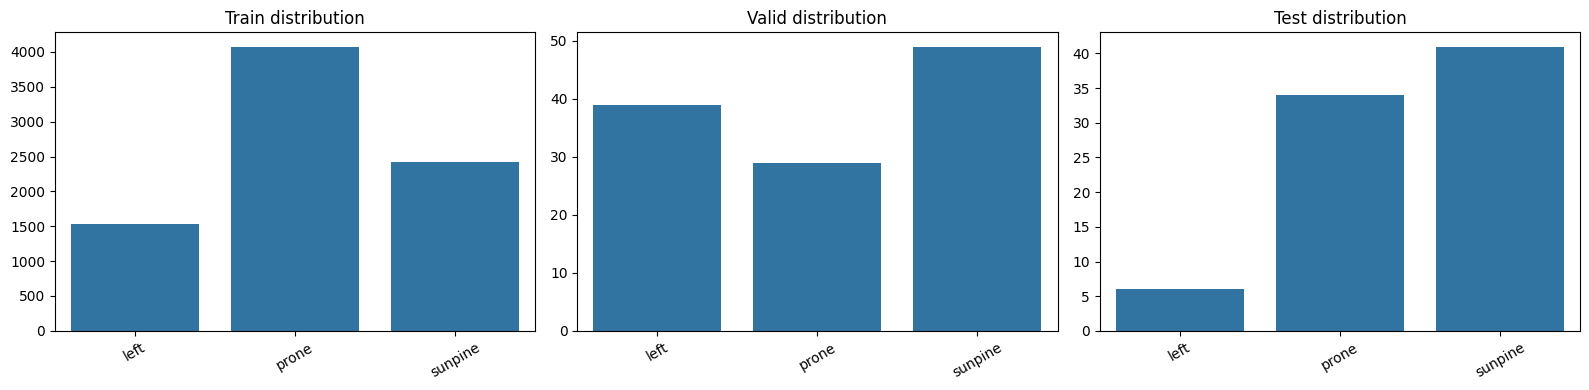

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, lbls) in zip(axes, [("Train", train_lbls), ("Valid", valid_lbls), ("Test", test_lbls)]):
    cnt = Counter(lbls)
    sns.barplot(x=list(cnt.keys()), y=list(cnt.values()), ax=ax)
    ax.set_title(f"{name} distribution"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

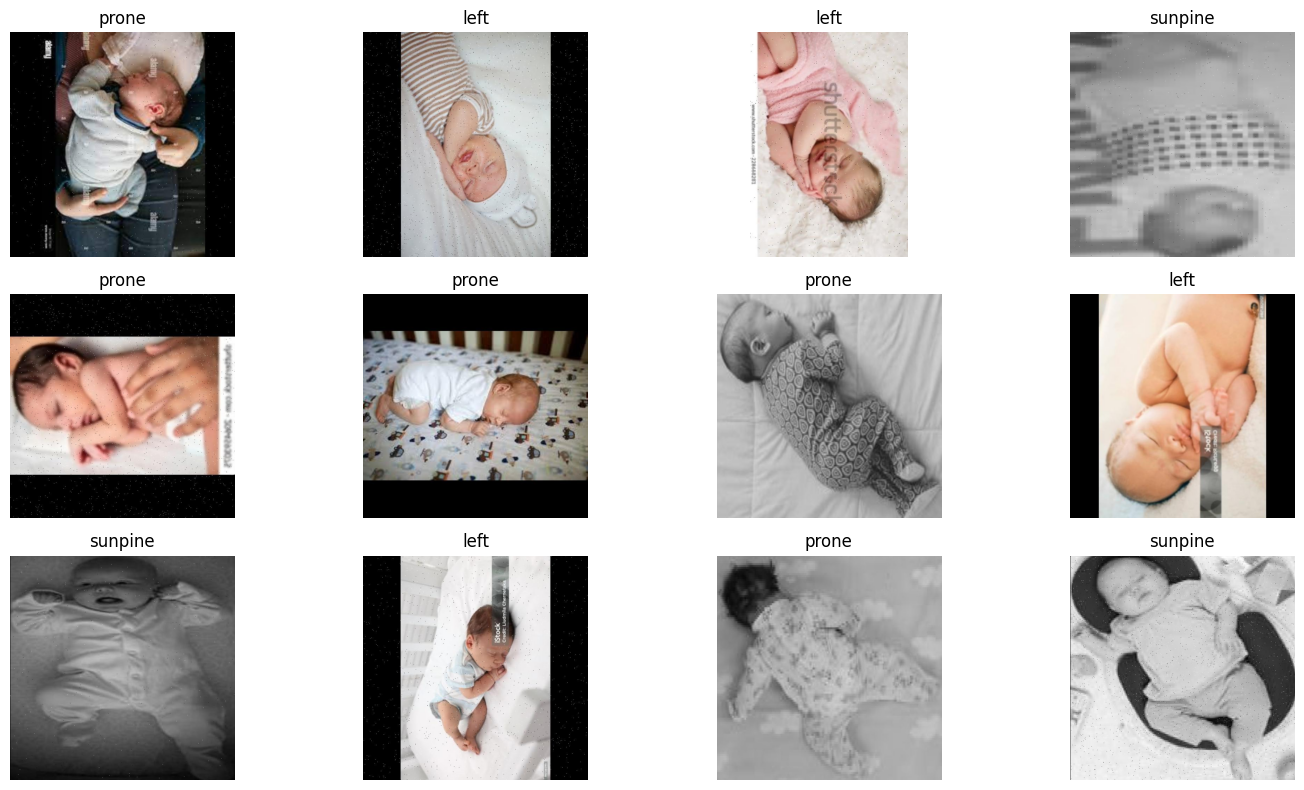

In [8]:
plt.figure(figsize=(15, 8))
idxs = random.sample(range(len(train_paths)), 12)
for i, idx in enumerate(idxs):
    plt.subplot(3, 4, i + 1)
    plt.imshow(Image.open(train_paths[idx]).convert("RGB"))
    plt.title(train_lbls[idx]); plt.axis("off")
plt.tight_layout(); plt.show()

In [9]:
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class PostureDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tfm(img), class_to_idx[self.labels[i]]

train_ds = PostureDataset(train_paths, train_lbls, train_tfms)
valid_ds = PostureDataset(valid_paths, valid_lbls, eval_tfms)
test_ds  = PostureDataset(test_paths,  test_lbls,  eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [10]:
def build_model(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    for p in model.features.parameters():          # Stage 1: freeze backbone
        p.requires_grad = False
    in_f = model.classifier[1].in_features         # 1280
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_f, num_classes))
    return model

model = build_model(NUM_CLASSES).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

counts  = Counter(train_lbls)
weights = torch.tensor([len(train_lbls) / (NUM_CLASSES * counts[c]) for c in class_names],
                       dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
print("Class weights:", dict(zip(class_names, weights.cpu().numpy().round(2))))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 185MB/s]


Total parameters: 2.23M
Class weights: {'left': np.float32(1.74), 'prone': np.float32(0.66), 'sunpine': np.float32(1.1)}


In [11]:
def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, correct, n = 0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            n          += x.size(0)
    return total_loss / n, correct / n

def fit(model, optimizer, scheduler, epochs, history, tag=""):
    best_wts = copy.deepcopy(model.state_dict())
    best_acc, bad = 0.0, 0
    for ep in range(epochs):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, optimizer)
        vl, va = run_epoch(model, valid_loader)
        scheduler.step(vl)
        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"], [tl, ta, vl, va]):
            history[k].append(v)
        print(f"{tag} Epoch {ep+1:02d}/{epochs} | train loss {tl:.4f} acc {ta:.4f} | "
              f"val loss {vl:.4f} acc {va:.4f} | {time.time()-t0:.0f}s")
        if va > best_acc:
            best_acc, best_wts, bad = va, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print("Early stopping."); break
    model.load_state_dict(best_wts)
    return model

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

In [12]:
opt   = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)
model = fit(model, opt, sched, epochs=8, history=history, tag="[Head]")

[Head] Epoch 01/8 | train loss 0.9281 acc 0.5484 | val loss 1.1503 acc 0.3077 | 61s
[Head] Epoch 02/8 | train loss 0.8430 acc 0.6202 | val loss 1.1245 acc 0.3504 | 45s
[Head] Epoch 03/8 | train loss 0.8243 acc 0.6346 | val loss 1.1166 acc 0.4188 | 45s
[Head] Epoch 04/8 | train loss 0.8052 acc 0.6438 | val loss 1.1875 acc 0.3675 | 45s
[Head] Epoch 05/8 | train loss 0.7990 acc 0.6489 | val loss 1.0336 acc 0.5812 | 44s
[Head] Epoch 06/8 | train loss 0.7943 acc 0.6555 | val loss 1.1735 acc 0.4103 | 44s
[Head] Epoch 07/8 | train loss 0.7872 acc 0.6572 | val loss 1.2460 acc 0.3932 | 45s
[Head] Epoch 08/8 | train loss 0.7944 acc 0.6577 | val loss 1.1493 acc 0.4444 | 46s


In [13]:
for p in model.parameters():
    p.requires_grad = True

opt   = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)
model = fit(model, opt, sched, epochs=EPOCHS, history=history, tag="[Fine]")

[Fine] Epoch 01/25 | train loss 0.6878 acc 0.7246 | val loss 1.3530 acc 0.3846 | 49s
[Fine] Epoch 02/25 | train loss 0.5168 acc 0.8371 | val loss 1.2738 acc 0.3932 | 49s
[Fine] Epoch 03/25 | train loss 0.4298 acc 0.8905 | val loss 1.4201 acc 0.3932 | 50s
[Fine] Epoch 04/25 | train loss 0.3851 acc 0.9167 | val loss 1.5146 acc 0.5214 | 49s
[Fine] Epoch 05/25 | train loss 0.3420 acc 0.9373 | val loss 1.5317 acc 0.4786 | 49s
[Fine] Epoch 06/25 | train loss 0.3084 acc 0.9569 | val loss 1.6006 acc 0.5214 | 50s
[Fine] Epoch 07/25 | train loss 0.2973 acc 0.9617 | val loss 1.5738 acc 0.5214 | 50s
[Fine] Epoch 08/25 | train loss 0.2903 acc 0.9695 | val loss 1.6549 acc 0.4786 | 50s
[Fine] Epoch 09/25 | train loss 0.2796 acc 0.9736 | val loss 1.7972 acc 0.4530 | 50s
[Fine] Epoch 10/25 | train loss 0.2753 acc 0.9763 | val loss 1.8119 acc 0.4530 | 51s
Early stopping.


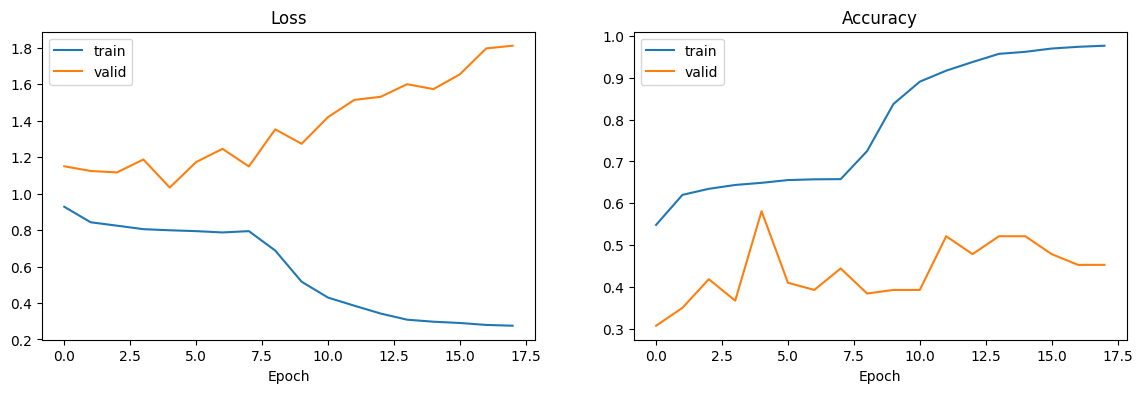

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="valid")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="valid")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.show()

In [15]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        y_pred += out.argmax(1).cpu().tolist()
        y_true += y.tolist()

print("Test accuracy:", round(accuracy_score(y_true, y_pred), 4))
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Test accuracy: 0.358
              precision    recall  f1-score   support

        left     0.1282    0.8333    0.2222         6
       prone     0.7000    0.2059    0.3182        34
     sunpine     0.5312    0.4146    0.4658        41

    accuracy                         0.3580        81
   macro avg     0.4532    0.4846    0.3354        81
weighted avg     0.5722    0.3580    0.3858        81



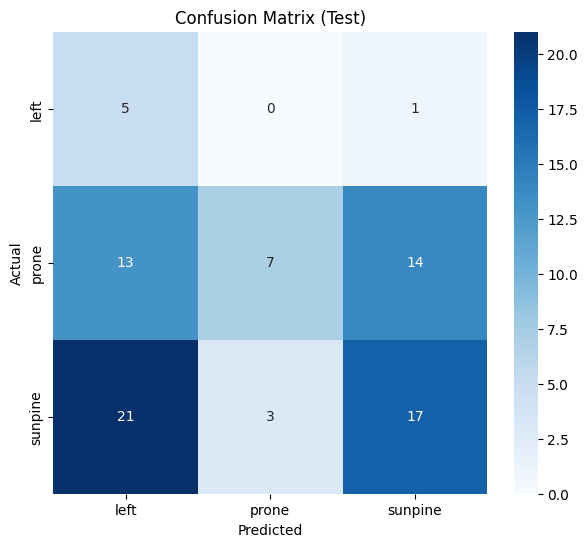

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (Test)")
plt.show()

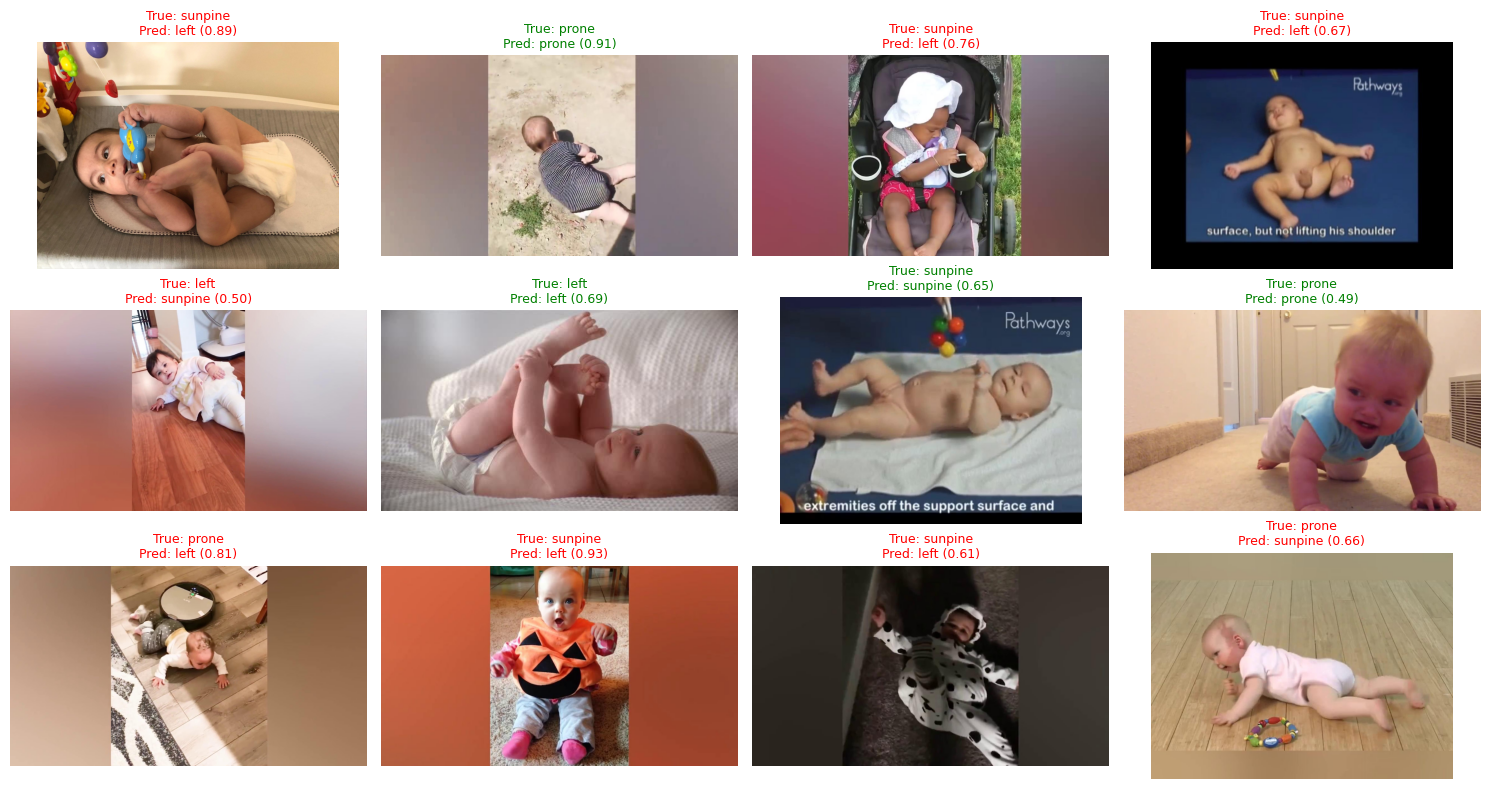

In [17]:
plt.figure(figsize=(15, 8))
idxs = random.sample(range(len(test_paths)), min(12, len(test_paths)))
model.eval()
for i, idx in enumerate(idxs):
    img = Image.open(test_paths[idx]).convert("RGB")
    with torch.no_grad():
        prob = torch.softmax(model(eval_tfms(img).unsqueeze(0).to(device)), 1)[0]
    pred  = class_names[prob.argmax().item()]
    color = "green" if pred == test_lbls[idx] else "red"
    plt.subplot(3, 4, i + 1); plt.imshow(img); plt.axis("off")
    plt.title(f"True: {test_lbls[idx]}\nPred: {pred} ({prob.max():.2f})", color=color, fontsize=9)
plt.tight_layout(); plt.show()

In [18]:
torch.save({"model_state": model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE}, "/kaggle/working/baby_sleep_posture_mobilenetv2.pth")
print("Saved to /kaggle/working/baby_sleep_posture_mobilenetv2.pth")

Saved to /kaggle/working/baby_sleep_posture_mobilenetv2.pth


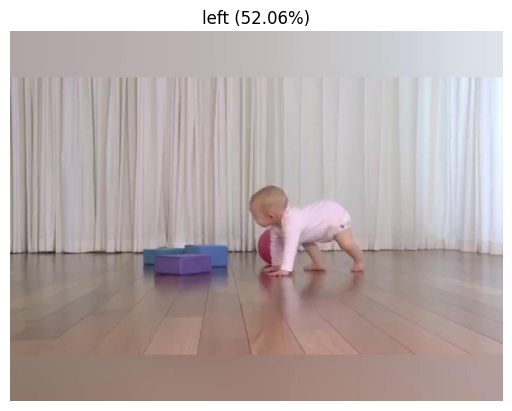

{'left': 0.5206, 'sunpine': 0.4488, 'prone': 0.0305}


In [19]:
def predict_image(path, topk=3):
    model.eval()
    img = Image.open(path).convert("RGB")
    with torch.no_grad():
        prob = torch.softmax(model(eval_tfms(img).unsqueeze(0).to(device)), 1)[0]
    top = prob.topk(min(topk, NUM_CLASSES))
    plt.imshow(img); plt.axis("off")
    plt.title(f"{class_names[top.indices[0]]} ({top.values[0]:.2%})"); plt.show()
    return {class_names[i]: round(v.item(), 4) for v, i in zip(top.values, top.indices)}

print(predict_image(test_paths[0]))

In [20]:
def evaluate(m, loader):
    m.eval(); yt, yp = [], []
    with torch.no_grad():
        for x, y in loader:
            yp += m(x.to(device)).argmax(1).cpu().tolist()
            yt += y.tolist()
    return accuracy_score(yt, yp), yt, yp

print("True label of test_paths[0]:", test_lbls[0], "\n")

train_eval_loader = DataLoader(PostureDataset(train_paths, train_lbls, eval_tfms),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

for name, ld in [("Train", train_eval_loader), ("Valid", valid_loader), ("Test", test_loader)]:
    acc, _, _ = evaluate(model, ld)
    print(f"{name:5s} accuracy: {acc:.4f}")

cnt = Counter(valid_lbls)
print(f"\nRandom guess   : {1/NUM_CLASSES:.3f}")
print(f"Majority class : {max(cnt.values())/len(valid_lbls):.3f}\n")

test_acc, yt, yp = evaluate(model, test_loader)
print(classification_report(yt, yp, target_names=class_names, digits=4, zero_division=0))

True label of test_paths[0]: left 

Train accuracy: 0.9482
Valid accuracy: 0.5214
Test  accuracy: 0.3580

Random guess   : 0.333
Majority class : 0.419

              precision    recall  f1-score   support

        left     0.1282    0.8333    0.2222         6
       prone     0.7000    0.2059    0.3182        34
     sunpine     0.5312    0.4146    0.4658        41

    accuracy                         0.3580        81
   macro avg     0.4532    0.4846    0.3354        81
weighted avg     0.5722    0.3580    0.3858        81



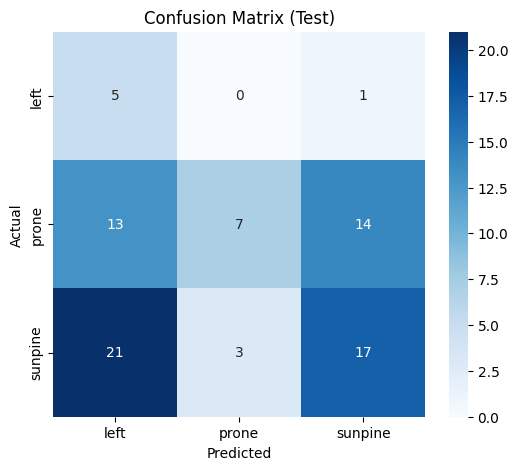

True labels     : Counter({'sunpine': 41, 'prone': 34, 'left': 6})
Predicted labels: Counter({'left': 39, 'sunpine': 32, 'prone': 10})


In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (Test)")
plt.show()

print("True labels     :", Counter(class_names[i] for i in yt))
print("Predicted labels:", Counter(class_names[i] for i in yp))

In [22]:
print("Split sizes -> train:", len(train_paths), "| valid:", len(valid_paths), "| test:", len(test_paths))
print("Train:", Counter(train_lbls))
print("Valid:", Counter(valid_lbls))
print("Test :", Counter(test_lbls))

def originals(paths): return {os.path.basename(p).split(".rf.")[0] for p in paths}
tr, va, te = originals(train_paths), originals(valid_paths), originals(test_paths)
print("\nUnique originals -> train:", len(tr), "| valid:", len(va), "| test:", len(te))
print("Train∩Valid:", len(tr & va), "| Train∩Test:", len(tr & te), "| Valid∩Test:", len(va & te))

Split sizes -> train: 8043 | valid: 117 | test: 81
Train: Counter({'prone': 4077, 'sunpine': 2427, 'left': 1539})
Valid: Counter({'sunpine': 49, 'left': 39, 'prone': 29})
Test : Counter({'sunpine': 41, 'prone': 34, 'left': 6})

Unique originals -> train: 1231 | valid: 117 | test: 81
Train∩Valid: 0 | Train∩Test: 12 | Valid∩Test: 0


In [23]:
torch.save({"model_state": model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE}, "/kaggle/working/baby_sleep_posture_mobilenetv2.pth")
print("Saved.")

Saved.


In [24]:
for p in train_paths[:4] + valid_paths[:4] + test_paths[:4]:
    print(os.path.basename(p))

Nanit_30_JPG_jpg.rf.02d14f6ef3830a7b4524deab7e74fb47.jpg
baby50_jpg.rf.9d03ba7cd20693c38a96b110f6b0dfc9.jpg
baby21_jpg.rf.9b2ed06e9df8de137df55e262e907847.jpg
download-54-_jpg.rf.68f15cd9bf15b701ec9ea73e7eff9a31.jpg
S01_015_jpg.rf.45210797533c06bc40989b5ec8df5c87.jpg
S05_009_jpg.rf.36b407a26107d5e20b6a85528ccd980c.jpg
S05_008_jpg.rf.a385f77c1a4822879cb79e7a98ae7546.jpg
S01_016_jpg.rf.913d43d23ccde2bc3f1e91fff659a601.jpg
199_jpg.rf.1670621b24f09f876dabfb508b9aa92b.jpg
265_jpg.rf.691b8512791049a942a8877c4f8d1b90.jpg
100_jpg.rf.9817bccd785d06cd964e72fa62551962.jpg
63_jpg.rf.a861c7f6c3dbd0a50eba66b6724626b3.jpg


In [25]:
rng = np.random.default_rng(0)
yt_a, yp_a = np.array(yt), np.array(yp)
accs = [(yt_a[i] == yp_a[i]).mean()
        for i in (rng.integers(0, len(yt_a), len(yt_a)) for _ in range(2000))]
lo, hi = np.percentile(accs, [2.5, 97.5])
print(f"Test accuracy 95% interval: {lo:.3f} - {hi:.3f}")

Test accuracy 95% interval: 0.259 - 0.457


In [26]:
import re
def style(p):
    n = os.path.basename(p).split(".rf.")[0]
    return "S##_### (sequence)" if re.match(r"S\d+_\d+", n) else "plain number"

for name, paths in [("Train", train_paths), ("Valid", valid_paths), ("Test", test_paths)]:
    print(name, Counter(style(p) for p in paths))

Train Counter({'plain number': 8043})
Valid Counter({'S##_### (sequence)': 117})
Test Counter({'plain number': 81})


In [27]:
def orig_id(p): return os.path.basename(p).split(".rf.")[0]

rows, seen = [], set()
order = list(range(len(train_paths))); random.Random(SEED).shuffle(order)
for i in order:                                   # drop augmented copies in train
    oid = orig_id(train_paths[i])
    if oid in seen: continue
    seen.add(oid); rows.append((train_paths[i], train_lbls[i], "train"))
rows += [(p, l, "valid") for p, l in zip(valid_paths, valid_lbls)]
rows += [(p, l, "test")  for p, l in zip(test_paths,  test_lbls)]

pool = pd.DataFrame(rows, columns=["path", "label", "old_split"])
print("Pooled images:", len(pool))
print(pool.label.value_counts())

Pooled images: 1429
label
prone      749
left       402
sunpine    278
Name: count, dtype: int64


In [28]:
feat = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features.to(device).eval()
emb_loader = DataLoader(PostureDataset(pool.path.tolist(), pool.label.tolist(), eval_tfms),
                        batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
embs = []
with torch.no_grad():
    for x, _ in emb_loader:
        f = feat(x.to(device)).mean([2, 3])
        embs.append(torch.nn.functional.normalize(f, dim=1).cpu())
E = torch.cat(embs).numpy()
print("Embeddings:", E.shape)

Embeddings: (1429, 1280)


In [29]:
from sklearn.cluster import AgglomerativeClustering

THRESH = 0.30        # lower = more, smaller groups; higher = fewer, bigger groups
cl = AgglomerativeClustering(n_clusters=None, metric="cosine", linkage="average",
                             distance_threshold=THRESH).fit(E)
pool["group"] = cl.labels_

sizes = pool.group.value_counts()
print("Groups:", pool.group.nunique(), "| largest 5 group sizes:", sizes.head(5).tolist())
print("Groups spanning more than one old split:",
      int((pool.groupby("group").old_split.nunique() > 1).sum()))

Groups: 777 | largest 5 group sizes: [45, 20, 20, 19, 15]
Groups spanning more than one old split: 3


In [30]:
from sklearn.model_selection import StratifiedGroupKFold

y = pool.label.map(class_to_idx).values
sgkf = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
folds = [te for _, te in sgkf.split(pool, y, pool.group)]

pool["split"] = "train"
pool.loc[pool.index[folds[0]], "split"] = "test"
pool.loc[pool.index[folds[1]], "split"] = "valid"

for s in ["train", "valid", "test"]:
    d = pool[pool.split == s]
    print(f"{s:5s} n={len(d):4d}", dict(Counter(d.label)))

g = pool.groupby("group").split.nunique()
print("Groups shared between splits (must be 0):", int((g > 1).sum()))

train n= 899 {'left': 261, 'sunpine': 199, 'prone': 439}
valid n= 197 {'left': 49, 'prone': 114, 'sunpine': 34}
test  n= 333 {'left': 92, 'prone': 196, 'sunpine': 45}
Groups shared between splits (must be 0): 0


In [31]:
def get(s):
    d = pool[pool.split == s]
    return d.path.tolist(), d.label.tolist()

train_paths2, train_lbls2 = get("train")
valid_paths2, valid_lbls2 = get("valid")
test_paths2,  test_lbls2  = get("test")

train_tfms2 = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.3),
])   # no horizontal flip: it would corrupt the 'left' class

train_loader = DataLoader(PostureDataset(train_paths2, train_lbls2, train_tfms2),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(PostureDataset(valid_paths2, valid_lbls2, eval_tfms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(PostureDataset(test_paths2, test_lbls2, eval_tfms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
for p in model.features.parameters():
    p.requires_grad = False
model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(1280, NUM_CLASSES))
model = model.to(device)

counts  = Counter(train_lbls2)
weights = torch.tensor([len(train_lbls2) / (NUM_CLASSES * counts[c]) for c in class_names],
                       dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
print("Class weights:", dict(zip(class_names, weights.cpu().numpy().round(2))))

Class weights: {'left': np.float32(1.15), 'prone': np.float32(0.68), 'sunpine': np.float32(1.51)}


In [32]:
def get(s):
    d = pool[pool.split == s]
    return d.path.tolist(), d.label.tolist()

train_paths2, train_lbls2 = get("train")
valid_paths2, valid_lbls2 = get("valid")
test_paths2,  test_lbls2  = get("test")

train_tfms2 = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.3),
])   # no horizontal flip: it would corrupt the 'left' class

train_loader = DataLoader(PostureDataset(train_paths2, train_lbls2, train_tfms2),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(PostureDataset(valid_paths2, valid_lbls2, eval_tfms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(PostureDataset(test_paths2, test_lbls2, eval_tfms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
for p in model.features.parameters():
    p.requires_grad = False
model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(1280, NUM_CLASSES))
model = model.to(device)

counts  = Counter(train_lbls2)
weights = torch.tensor([len(train_lbls2) / (NUM_CLASSES * counts[c]) for c in class_names],
                       dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
print("Class weights:", dict(zip(class_names, weights.cpu().numpy().round(2))))

Class weights: {'left': np.float32(1.15), 'prone': np.float32(0.68), 'sunpine': np.float32(1.51)}


In [33]:
def fit2(model, optimizer, epochs, patience, tag):
    best, best_wts, bad = 1e9, copy.deepcopy(model.state_dict()), 0
    for ep in range(epochs):
        tl, ta = run_epoch(model, train_loader, optimizer)
        vl, va = run_epoch(model, valid_loader)
        print(f"{tag} {ep+1:02d}/{epochs} | train loss {tl:.3f} acc {ta:.3f} | val loss {vl:.3f} acc {va:.3f}")
        if vl < best:
            best, best_wts, bad = vl, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience: print("Early stop."); break
    model.load_state_dict(best_wts)
    return model

In [34]:
opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
model = fit2(model, opt, epochs=12, patience=3, tag="[Head]")

[Head] 01/12 | train loss 1.126 acc 0.339 | val loss 1.084 acc 0.391
[Head] 02/12 | train loss 1.053 acc 0.433 | val loss 1.098 acc 0.381
[Head] 03/12 | train loss 1.026 acc 0.471 | val loss 1.064 acc 0.426
[Head] 04/12 | train loss 1.015 acc 0.464 | val loss 1.061 acc 0.472
[Head] 05/12 | train loss 1.009 acc 0.518 | val loss 1.061 acc 0.442
[Head] 06/12 | train loss 0.979 acc 0.526 | val loss 1.061 acc 0.416
[Head] 07/12 | train loss 0.984 acc 0.535 | val loss 1.047 acc 0.472
[Head] 08/12 | train loss 0.977 acc 0.546 | val loss 1.062 acc 0.411
[Head] 09/12 | train loss 0.964 acc 0.541 | val loss 1.047 acc 0.452
[Head] 10/12 | train loss 0.949 acc 0.548 | val loss 1.013 acc 0.579
[Head] 11/12 | train loss 0.958 acc 0.549 | val loss 1.027 acc 0.548
[Head] 12/12 | train loss 0.958 acc 0.545 | val loss 1.036 acc 0.462


In [35]:
for p in model.features[14:].parameters():
    p.requires_grad = True

opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=1e-2)
model = fit2(model, opt, epochs=10, patience=3, tag="[Fine]")

[Fine] 01/10 | train loss 0.954 acc 0.584 | val loss 1.011 acc 0.528
[Fine] 02/10 | train loss 0.925 acc 0.592 | val loss 1.000 acc 0.584
[Fine] 03/10 | train loss 0.891 acc 0.594 | val loss 0.988 acc 0.604
[Fine] 04/10 | train loss 0.887 acc 0.621 | val loss 0.999 acc 0.579
[Fine] 05/10 | train loss 0.878 acc 0.630 | val loss 0.995 acc 0.558
[Fine] 06/10 | train loss 0.869 acc 0.635 | val loss 0.986 acc 0.569
[Fine] 07/10 | train loss 0.856 acc 0.653 | val loss 0.975 acc 0.584
[Fine] 08/10 | train loss 0.836 acc 0.673 | val loss 0.984 acc 0.528
[Fine] 09/10 | train loss 0.820 acc 0.679 | val loss 0.974 acc 0.543
[Fine] 10/10 | train loss 0.816 acc 0.662 | val loss 0.951 acc 0.599


Valid accuracy: 0.5990
Test accuracy: 0.5526
              precision    recall  f1-score   support

        left     0.3852    0.5109    0.4393        92
       prone     0.7832    0.5714    0.6608       196
     sunpine     0.3676    0.5556    0.4425        45

    accuracy                         0.5526       333
   macro avg     0.5120    0.5460    0.5142       333
weighted avg     0.6171    0.5526    0.5701       333

True     : Counter({'prone': 196, 'left': 92, 'sunpine': 45})
Predicted: Counter({'prone': 143, 'left': 122, 'sunpine': 68})


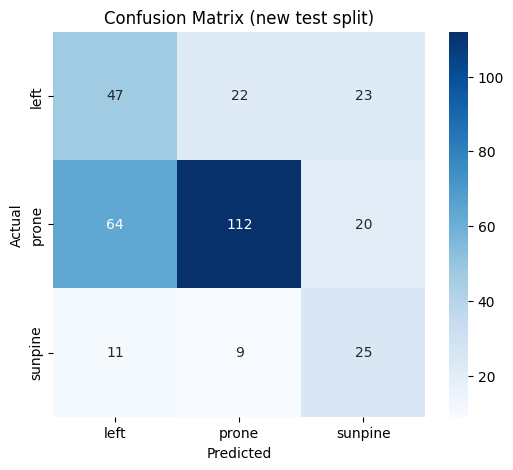

Test accuracy 95% interval: 0.502 - 0.604


In [36]:
for name, ld in [("Valid", valid_loader), ("Test", test_loader)]:
    acc, _, _ = evaluate(model, ld)
    print(f"{name} accuracy: {acc:.4f}")

_, yt, yp = evaluate(model, test_loader)
print(classification_report(yt, yp, target_names=class_names, digits=4, zero_division=0))
print("True     :", Counter(class_names[i] for i in yt))
print("Predicted:", Counter(class_names[i] for i in yp))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (new test split)")
plt.show()

rng = np.random.default_rng(0)
a, b = np.array(yt), np.array(yp)
accs = [(a[i] == b[i]).mean() for i in (rng.integers(0, len(a), len(a)) for _ in range(2000))]
lo, hi = np.percentile(accs, [2.5, 97.5])
print(f"Test accuracy 95% interval: {lo:.3f} - {hi:.3f}")

In [37]:
mobilenet_model = model

def summarize(m, name):
    acc, yt, yp = evaluate(m, test_loader)
    rep = classification_report(yt, yp, target_names=class_names, output_dict=True, zero_division=0)
    row = {"Model": name, "Test Acc": round(acc, 4), "Macro F1": round(rep["macro avg"]["f1-score"], 4)}
    for c in class_names:
        row[f"Recall {c}"] = round(rep[c]["recall"], 4)
    return row

results = [summarize(mobilenet_model, "MobileNetV2")]
print(results[0])

{'Model': 'MobileNetV2', 'Test Acc': 0.5526, 'Macro F1': 0.5142, 'Recall left': 0.5109, 'Recall prone': 0.5714, 'Recall sunpine': 0.5556}


In [38]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1, bias=False),
                                 nn.BatchNorm2d(o), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

cnn_model = BaselineCNN(NUM_CLASSES).to(device)
opt = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-2)
cnn_model = fit2(cnn_model, opt, epochs=40, patience=8, tag="[CNN]")
results.append(summarize(cnn_model, "Baseline CNN"))
print(results[-1])

[CNN] 01/40 | train loss 1.204 acc 0.318 | val loss 1.124 acc 0.294
[CNN] 02/40 | train loss 1.129 acc 0.309 | val loss 1.074 acc 0.350
[CNN] 03/40 | train loss 1.122 acc 0.330 | val loss 1.075 acc 0.340
[CNN] 04/40 | train loss 1.098 acc 0.360 | val loss 1.052 acc 0.462
[CNN] 05/40 | train loss 1.116 acc 0.373 | val loss 1.125 acc 0.315
[CNN] 06/40 | train loss 1.096 acc 0.356 | val loss 1.095 acc 0.279
[CNN] 07/40 | train loss 1.086 acc 0.383 | val loss 1.088 acc 0.431
[CNN] 08/40 | train loss 1.094 acc 0.373 | val loss 1.064 acc 0.345
[CNN] 09/40 | train loss 1.092 acc 0.397 | val loss 1.075 acc 0.447
[CNN] 10/40 | train loss 1.107 acc 0.330 | val loss 1.053 acc 0.442
[CNN] 11/40 | train loss 1.077 acc 0.418 | val loss 1.102 acc 0.310
[CNN] 12/40 | train loss 1.091 acc 0.347 | val loss 1.113 acc 0.320
Early stop.
{'Model': 'Baseline CNN', 'Test Acc': 0.5165, 'Macro F1': 0.3489, 'Recall left': 0.0109, 'Recall prone': 0.7551, 'Recall sunpine': 0.5111}


In [39]:
eff_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
for p in eff_model.features.parameters():
    p.requires_grad = False
eff_model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(1280, NUM_CLASSES))
eff_model = eff_model.to(device)

opt = optim.AdamW(filter(lambda p: p.requires_grad, eff_model.parameters()), lr=1e-3, weight_decay=1e-2)
eff_model = fit2(eff_model, opt, epochs=12, patience=3, tag="[EffHead]")

for p in eff_model.features[6:].parameters():
    p.requires_grad = True
opt = optim.AdamW(filter(lambda p: p.requires_grad, eff_model.parameters()), lr=5e-5, weight_decay=1e-2)
eff_model = fit2(eff_model, opt, epochs=10, patience=3, tag="[EffFine]")

results.append(summarize(eff_model, "EfficientNet-B0"))
print(results[-1])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 250MB/s]


[EffHead] 01/12 | train loss 1.108 acc 0.349 | val loss 1.085 acc 0.401
[EffHead] 02/12 | train loss 1.032 acc 0.494 | val loss 1.104 acc 0.386
[EffHead] 03/12 | train loss 1.013 acc 0.501 | val loss 1.078 acc 0.411
[EffHead] 04/12 | train loss 1.007 acc 0.495 | val loss 1.051 acc 0.457
[EffHead] 05/12 | train loss 0.989 acc 0.521 | val loss 1.025 acc 0.503
[EffHead] 06/12 | train loss 0.971 acc 0.525 | val loss 1.007 acc 0.492
[EffHead] 07/12 | train loss 0.967 acc 0.547 | val loss 1.033 acc 0.452
[EffHead] 08/12 | train loss 0.955 acc 0.546 | val loss 1.033 acc 0.462
[EffHead] 09/12 | train loss 0.974 acc 0.547 | val loss 1.007 acc 0.553
Early stop.
[EffFine] 01/10 | train loss 0.950 acc 0.570 | val loss 1.003 acc 0.543
[EffFine] 02/10 | train loss 0.919 acc 0.594 | val loss 0.990 acc 0.574
[EffFine] 03/10 | train loss 0.894 acc 0.592 | val loss 0.977 acc 0.553
[EffFine] 04/10 | train loss 0.877 acc 0.618 | val loss 0.968 acc 0.589
[EffFine] 05/10 | train loss 0.875 acc 0.615 | val l

In [40]:
display(pd.DataFrame(results).set_index("Model"))

,Test Acc,Macro F1,Recall left,Recall prone,Recall sunpine
Model,,,,,
MobileNetV2,0.5526,0.5142,0.5109,0.5714,0.5556
Baseline CNN,0.5165,0.3489,0.0109,0.7551,0.5111
EfficientNet-B0,0.5586,0.5060,0.5000,0.6071,0.4667


In [41]:
torch.save({"model_state": eff_model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE,
            "arch": "efficientnet_b0"}, "/kaggle/working/baby_sleep_posture_effnetb0_final.pth")
torch.save({"model_state": mobilenet_model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE,
            "arch": "mobilenet_v2"}, "/kaggle/working/baby_sleep_posture_mobilenetv2_final.pth")
print("Saved both.")

Saved both.


              precision    recall  f1-score   support

        left     0.3898    0.5000    0.4381        92
       prone     0.7628    0.6071    0.6761       196
     sunpine     0.3559    0.4667    0.4038        45

    accuracy                         0.5586       333
   macro avg     0.5029    0.5246    0.5060       333
weighted avg     0.6048    0.5586    0.5736       333



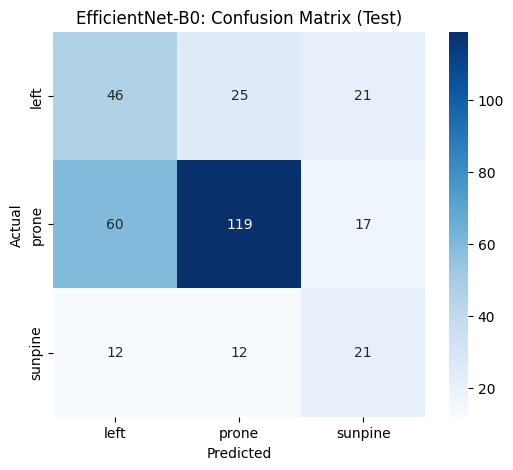

Test accuracy 95% interval: 0.505 - 0.610


In [42]:
acc, yt, yp = evaluate(eff_model, test_loader)
print(classification_report(yt, yp, target_names=class_names, digits=4, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("EfficientNet-B0: Confusion Matrix (Test)")
plt.show()

rng = np.random.default_rng(0)
a, b = np.array(yt), np.array(yp)
accs = [(a[i] == b[i]).mean() for i in (rng.integers(0, len(a), len(a)) for _ in range(2000))]
lo, hi = np.percentile(accs, [2.5, 97.5])
print(f"Test accuracy 95% interval: {lo:.3f} - {hi:.3f}")

In [43]:
def size_mb(m):
    torch.save(m.state_dict(), "/kaggle/working/_t.pth")
    s = os.path.getsize("/kaggle/working/_t.pth") / 1e6
    os.remove("/kaggle/working/_t.pth"); return s

def latency_ms(m, runs=100):
    m.eval(); x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    with torch.no_grad():
        for _ in range(10): m(x)
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(runs): m(x)
        if device.type == "cuda": torch.cuda.synchronize()
    return (time.time() - t0) / runs * 1000

rows = []
for n, m in [("Baseline CNN", cnn_model), ("MobileNetV2", mobilenet_model), ("EfficientNet-B0", eff_model)]:
    rows.append({"Model": n,
                 "Params (M)": round(sum(p.numel() for p in m.parameters()) / 1e6, 2),
                 "Size (MB)": round(size_mb(m), 1),
                 "Latency (ms/img)": round(latency_ms(m), 2)})
display(pd.DataFrame(rows).set_index("Model"))

,Params (M),Size (MB),Latency (ms/img)
Model,,,
Baseline CNN,0.39,1.6,0.80
MobileNetV2,2.23,9.1,5.03
EfficientNet-B0,4.01,16.3,8.25


In [44]:
!pip install -q onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.0 MB/s eta 0:00:00


In [45]:
eff_model.eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
torch.onnx.export(eff_model, dummy, "/kaggle/working/baby_sleep_posture_effnetb0.onnx",
                  input_names=["image"], output_names=["logits"],
                  dynamic_axes={"image": {0: "batch"}}, opset_version=17)
print("ONNX saved.")

W1005 04:55:21.532000 23 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str,

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX saved.


In [46]:
import onnxruntime as ort, os

path = "/kaggle/working/baby_sleep_posture_effnetb0.onnx"
print("File size (MB):", round(os.path.getsize(path) / 1e6, 1))

sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])

x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    torch_out = eff_model(x.to(device)).cpu().numpy()
onnx_out = sess.run(None, {"image": x.numpy()})[0]

print("Max difference:", float(np.abs(torch_out - onnx_out).max()))
print("Same predictions:", bool((torch_out.argmax(1) == onnx_out.argmax(1)).all()))

File size (MB): 0.6
Max difference: 0.5111083984375
Same predictions: True


In [47]:
for f in sorted(os.listdir("/kaggle/working")):
    print(f"{f:55s} {os.path.getsize('/kaggle/working/'+f)/1e6:8.1f} MB")

__notebook__.ipynb                                           3.9 MB
baby_sleep_posture_effnetb0.onnx                             0.6 MB
baby_sleep_posture_effnetb0.onnx.data                       16.1 MB
baby_sleep_posture_effnetb0_final.pth                       16.4 MB
baby_sleep_posture_mobilenetv2.pth                           9.2 MB
baby_sleep_posture_mobilenetv2_final.pth                     9.2 MB


In [48]:
import onnx

eff_model.eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
torch.onnx.export(eff_model, dummy, "/kaggle/working/tmp_effnet.onnx",
                  input_names=["image"], output_names=["logits"],
                  dynamic_axes={"image": {0: "batch"}}, opset_version=17, dynamo=False)

m = onnx.load("/kaggle/working/tmp_effnet.onnx", load_external_data=True)
onnx.save(m, "/kaggle/working/baby_sleep_posture_effnetb0.onnx", save_as_external_data=False)

for f in os.listdir("/kaggle/working"):
    if f.startswith("tmp_effnet"): os.remove(os.path.join("/kaggle/working", f))
for f in ["baby_sleep_posture_effnetb0.onnx.data"]:
    p = os.path.join("/kaggle/working", f)
    if os.path.exists(p): os.remove(p)

print("Size (MB):", round(os.path.getsize("/kaggle/working/baby_sleep_posture_effnetb0.onnx")/1e6, 1))

Size (MB): 16.0


In [49]:
import onnxruntime as ort
sess = ort.InferenceSession("/kaggle/working/baby_sleep_posture_effnetb0.onnx",
                            providers=["CPUExecutionProvider"])

batch = torch.stack([eval_tfms(Image.open(p).convert("RGB")) for p in test_paths2[:16]])
eff_model.eval()
with torch.no_grad():
    torch_out = eff_model(batch.to(device)).cpu().numpy()
onnx_out = sess.run(None, {"image": batch.numpy()})[0]

print("Max difference:", float(np.abs(torch_out - onnx_out).max()))
print("Same predictions:", bool((torch_out.argmax(1) == onnx_out.argmax(1)).all()))

Max difference: 8.118152618408203e-05
Same predictions: True


In [50]:
import json
comp = pd.DataFrame(results).set_index("Model")
comp.to_csv("/kaggle/working/model_comparison.csv")
json.dump(class_names, open("/kaggle/working/class_names.json", "w"))
print(comp)
print("Class order:", class_names)

                 Test Acc  Macro F1  Recall left  Recall prone  Recall sunpine
Model                                                                         
MobileNetV2        0.5526    0.5142       0.5109        0.5714          0.5556
Baseline CNN       0.5165    0.3489       0.0109        0.7551          0.5111
EfficientNet-B0    0.5586    0.5060       0.5000        0.6071          0.4667
Class order: ['left', 'prone', 'sunpine']
